In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

In [2]:
# Set seed for reproducibility
np.random.seed(42)

# Load data
df = pd.read_csv('portugal_listinigs.csv')
df.head()

/tmp/ipykernel_2070/3582540689.py:5: DtypeWarning: Columns (6,8,12,13,14,15,16,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('portugal_listinigs.csv')


,Price,District,City,Town,Type,EnergyCertificate,Floor,Parking,HasParking,ConstructionYear,...,Elevator,ElectricCarsCharging,TotalRooms,NumberOfBedrooms,NumberOfWC,ConservationStatus,LivingArea,LotSize,BuiltArea,NumberOfBathrooms
0,250000.0,Faro,São Brás de Alportel,São Brás de Alportel,Apartment,A+,2nd Floor,1.0,True,NaN,...,True,NaN,2.0,NaN,NaN,NaN,114.0,NaN,NaN,2.0
1,9500.0,Faro,Albufeira,Albufeira e Olhos de Água,Apartment,NC,1st Floor,0.0,False,1990.0,...,True,NaN,0.0,NaN,NaN,NaN,27.0,NaN,NaN,1.0
2,580000.0,Faro,Vila do Bispo,Budens,Apartment,D,3rd Floor,1.0,True,2003.0,...,False,NaN,2.0,NaN,NaN,NaN,84.0,NaN,NaN,2.0
3,350000.0,Faro,Portimão,Portimão,Apartment,C,4th Floor,0.0,False,1985.0,...,True,NaN,2.0,NaN,NaN,NaN,68.0,NaN,NaN,1.0
4,175000.0,Faro,Faro,Faro (Sé e São Pedro),House,NC,NaN,0.0,False,1950.0,...,False,NaN,4.0,NaN,NaN,NaN,78.0,NaN,NaN,2.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120826 entries, 0 to 120825
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Price                  120545 non-null  float64
 1   District               120826 non-null  object 
 2   City                   120826 non-null  object 
 3   Town                   120824 non-null  object 
 4   Type                   120810 non-null  object 
 5   EnergyCertificate      120812 non-null  object 
 6   Floor                  27929 non-null   object 
 7   Parking                120632 non-null  float64
 8   HasParking             68215 non-null   object 
 9   ConstructionYear       78228 non-null   float64
 10  TotalArea              113782 non-null  float64
 11  GrossArea              27638 non-null   float64
 12  EnergyEfficiencyLevel  52579 non-null   object 
 13  PublishDate            19224 non-null   object 
 14  Garage                 52579 non-nul

In [4]:
df.describe()

,Price,Parking,ConstructionYear,TotalArea,GrossArea,TotalRooms,NumberOfBedrooms,NumberOfWC,LivingArea,LotSize,BuiltArea,NumberOfBathrooms
count,1.205450e+05,120632.000000,78228.000000,1.137820e+05,2.763800e+04,67802.000000,35428.000000,46621.000000,9.252900e+04,3.209000e+04,2.097700e+04,115096.000000
mean,3.674658e+05,0.570520,1988.993596,5.742814e+05,2.789733e+03,3.151220,2.680253,0.412196,1.508726e+03,6.726420e+04,3.495683e+03,1.516273
std,4.024606e+06,0.870374,26.690061,1.821361e+08,1.153670e+05,10.880886,1.863235,1.021265,3.684470e+04,5.784162e+06,1.321013e+05,1.719349
min,1.000000e+00,0.000000,1900.000000,-7.196067e+06,-7.000000e+00,0.000000,0.000000,-15.000000,0.000000e+00,0.000000e+00,-1.000000e+00,-13.000000
25%,7.990000e+04,0.000000,1972.000000,9.400000e+01,1.000000e+02,2.000000,2.000000,0.000000,8.000000e+01,2.880000e+02,1.058000e+02,0.000000
50%,2.000000e+05,0.000000,1994.000000,1.710000e+02,1.640000e+02,3.000000,3.000000,0.000000,1.200000e+02,7.565000e+02,1.730000e+02,1.000000
75%,3.921000e+05,1.000000,2008.000000,5.800000e+02,2.940000e+02,4.000000,3.000000,0.000000,2.120000e+02,3.174750e+03,3.114500e+02,2.000000
max,1.380000e+09,3.000000,2024.000000,6.142007e+10,1.275000e+07,2751.000000,21.000000,59.000000,5.429000e+06,9.923010e+08,1.275000e+07,90.000000


In [5]:
# Drop values bellow 0 or 0 in the columns where that is not possible
df.drop(df[df['TotalArea'] <= 0].index, inplace=True)
df.drop(df[df['GrossArea'] <= 0].index, inplace=True)
df.drop(df[df['BuiltArea'] <= 0].index, inplace=True)
df.drop(df[df['NumberOfBathrooms'] < 0].index, inplace=True)
df.drop(columns='NumberOfWC', inplace=True)


In [6]:
def show_missing_data_with_percent(df):
    missing_values = df.isna().sum()
    missing_percentage = round((df.isna().sum() / len(df)) * 100, 2)
    missing_data = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
    print(missing_data)
show_missing_data_with_percent(df)

                       Missing Values  Percentage
Price                             279        0.23
District                            0        0.00
City                                0        0.00
Town                                2        0.00
Type                               16        0.01
EnergyCertificate                  14        0.01
Floor                           92307       77.17
Parking                           194        0.16
HasParking                      52262       43.69
ConstructionYear                42150       35.24
TotalArea                        7043        5.89
GrossArea                       92741       77.53
EnergyEfficiencyLevel           67392       56.34
PublishDate                    100471       83.99
Garage                          67392       56.34
Elevator                           32        0.03
ElectricCarsCharging            67392       56.34
TotalRooms                      52769       44.11
NumberOfBedrooms                84408       70.56


In [7]:
df.shape

(119622, 24)

In [8]:
df.dropna(subset=['Price', 'Town', 'EnergyCertificate', 'Elevator', 'Type', 'Parking'], inplace=True)
df.isna().sum()

Price                         0
District                      0
City                          0
Town                          0
Type                          0
EnergyCertificate             0
Floor                     91924
Parking                       0
HasParking                52090
ConstructionYear          41899
TotalArea                  7005
GrossArea                 92363
EnergyEfficiencyLevel     67055
PublishDate              100006
Garage                    67055
Elevator                      0
ElectricCarsCharging      67055
TotalRooms                52631
NumberOfBedrooms          84045
ConservationStatus       104218
LivingArea                28089
LotSize                   87450
BuiltArea                 98436
NumberOfBathrooms          5658
dtype: int64

In [9]:
df.shape

(119145, 24)

In [10]:
# Actual unique values for each column
for column in df.columns:
    if df[column].dtype == 'object':
        print(f"Unique values for {column}:")
        print(df[column].unique())
        print("\n")

Unique values for District:
['Faro' 'Vila Real' 'Porto' 'Lisboa' 'Guarda' 'Leiria' 'Viseu' 'Setúbal'
 'Coimbra' 'Castelo Branco' 'Ilha Terceira' 'Beja' 'Santarém' 'Aveiro'
 'Évora' 'Braga' 'Ilha de São Miguel' 'Portalegre' 'Bragança'
 'Viana do Castelo' 'Ilha da Madeira' 'Ilha de Porto Santo'
 'Ilha de Santa Maria' 'Ilha de São Jorge' 'Z - Fora de Portugal']


Unique values for City:
['São Brás de Alportel' 'Albufeira' 'Vila do Bispo' 'Portimão' 'Faro'
 'Loulé' 'Lagos' 'Alcoutim' 'Valpaços' 'Lagoa (Algarve)' 'Castro Marim'
 'Olhão' 'Vila Real de Santo António' 'Silves' 'Tavira' 'Aljezur' 'Porto'
 'Monchique' 'Sintra' 'Seia' 'Paços de Ferreira' 'Almeida' 'Gouveia'
 'Celorico da Beira' 'Mêda' 'Guarda' 'Trancoso' 'Matosinhos' 'Lisboa'
 'Fornos de Algodres' 'Ansião' 'Pinhel' 'Manteigas'
 'Figueira de Castelo Rodrigo' 'Tondela' 'Aguiar da Beira'
 'Vila Nova de Foz Côa' 'Setúbal' 'Sabugal' 'Azambuja' 'Coimbra'
 'Amarante' 'Marinha Grande' 'Sertã' 'Gondomar' 'Praia da Vitória'
 'Alvito' 'Seix

In [11]:
missing = df.isnull().sum()/len(df)
missing = missing[missing >= 0.8]
missing.sort_values(inplace=True)
print(missing)
df.drop(columns=missing.index, inplace=True)

BuiltArea             0.826187
PublishDate           0.839364
ConservationStatus    0.874716
dtype: float64


In [12]:
show_missing_data_with_percent(df)
# Correct the data types
df['City'] = df['City'].astype(str)
df['Town'] = df['Town'].astype(str)
df['Type'] = df['Type'].astype(str)
df['EnergyCertificate'] = df['EnergyCertificate'].astype(str)
df.dtypes

                       Missing Values  Percentage
Price                               0        0.00
District                            0        0.00
City                                0        0.00
Town                                0        0.00
Type                                0        0.00
EnergyCertificate                   0        0.00
Floor                           91924       77.15
Parking                             0        0.00
HasParking                      52090       43.72
ConstructionYear                41899       35.17
TotalArea                        7005        5.88
GrossArea                       92363       77.52
EnergyEfficiencyLevel           67055       56.28
Garage                          67055       56.28
Elevator                            0        0.00
ElectricCarsCharging            67055       56.28
TotalRooms                      52631       44.17
NumberOfBedrooms                84045       70.54
LivingArea                      28089       23.58


Price                    float64
District                  object
City                      object
Town                      object
Type                      object
EnergyCertificate         object
Floor                     object
Parking                  float64
HasParking                object
ConstructionYear         float64
TotalArea                float64
GrossArea                float64
EnergyEfficiencyLevel     object
Garage                    object
Elevator                  object
ElectricCarsCharging      object
TotalRooms               float64
NumberOfBedrooms         float64
LivingArea               float64
LotSize                  float64
NumberOfBathrooms        float64
dtype: object

In [13]:
show_missing_data_with_percent(df)
# Correct the data types
df['City'] = df['City'].astype(str)
df['Town'] = df['Town'].astype(str)
df['Type'] = df['Type'].astype(str)
df['EnergyCertificate'] = df['EnergyCertificate'].astype(str)
df.dtypes

                       Missing Values  Percentage
Price                               0        0.00
District                            0        0.00
City                                0        0.00
Town                                0        0.00
Type                                0        0.00
EnergyCertificate                   0        0.00
Floor                           91924       77.15
Parking                             0        0.00
HasParking                      52090       43.72
ConstructionYear                41899       35.17
TotalArea                        7005        5.88
GrossArea                       92363       77.52
EnergyEfficiencyLevel           67055       56.28
Garage                          67055       56.28
Elevator                            0        0.00
ElectricCarsCharging            67055       56.28
TotalRooms                      52631       44.17
NumberOfBedrooms                84045       70.54
LivingArea                      28089       23.58


Price                    float64
District                  object
City                      object
Town                      object
Type                      object
EnergyCertificate         object
Floor                     object
Parking                  float64
HasParking                object
ConstructionYear         float64
TotalArea                float64
GrossArea                float64
EnergyEfficiencyLevel     object
Garage                    object
Elevator                  object
ElectricCarsCharging      object
TotalRooms               float64
NumberOfBedrooms         float64
LivingArea               float64
LotSize                  float64
NumberOfBathrooms        float64
dtype: object

(119145, 21)


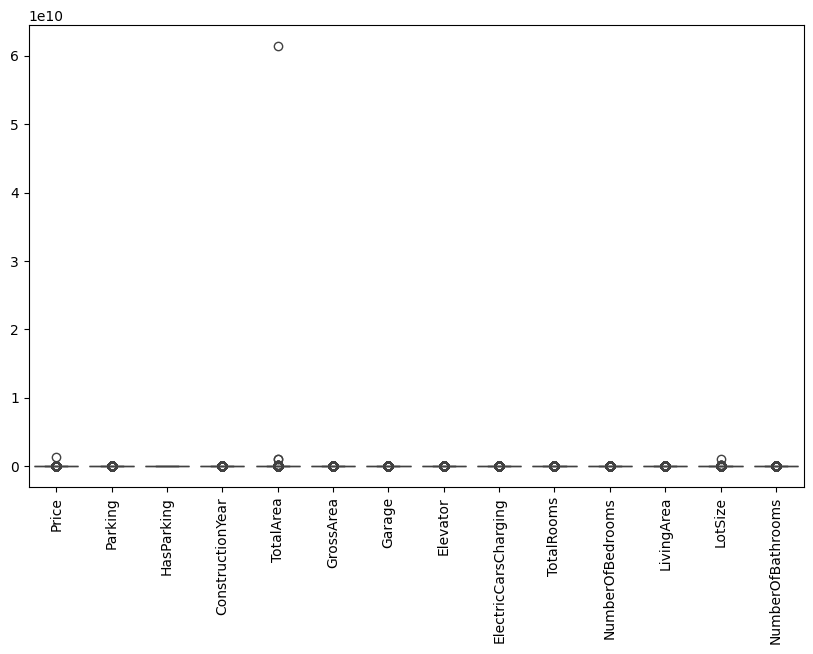

In [14]:
# Display the shape of the dataframe before removing outliers
print(df.shape)
#check outliers boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [15]:
# Select float64 columns
df_float64 = df.select_dtypes(include=['float64'])

# Calculate mean and standard deviation for each float64 column
mean_values = df_float64.mean()
std_values = df_float64.std()

# Define a function to identify outliers
def is_outlier(value, mean, std, threshold=3):
    return abs(value - mean) > threshold * std

# Identify and remove outliers
for column in df_float64.columns:
    mean = mean_values[column]
    std = std_values[column]
    df = df[~df[column].apply(is_outlier, args=(mean, std))]

(117320, 21)


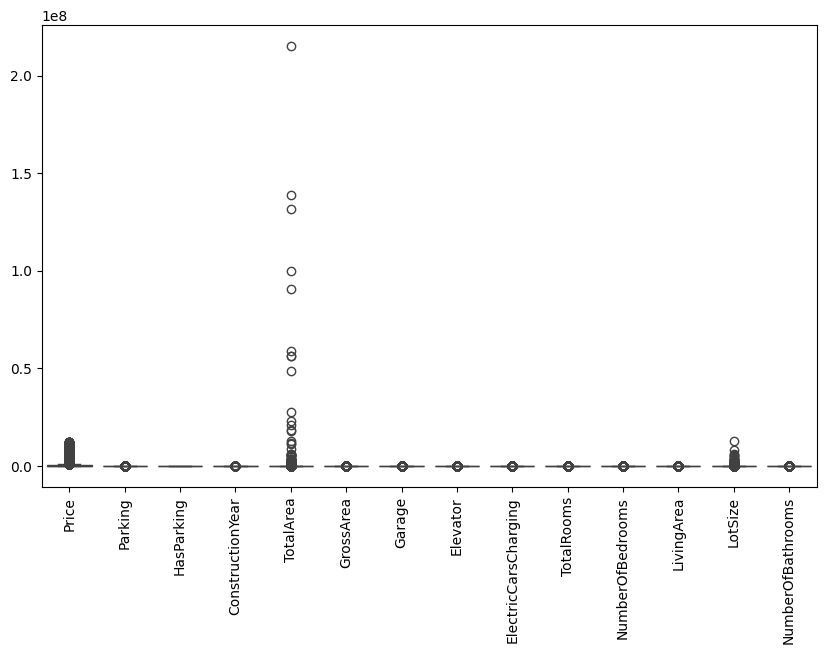

In [16]:
# Display the shape of the dataframe after removing outliers
print(df.shape)
# Check outliers boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [17]:
# drop the variables that are not valuable
df.drop(columns=['EnergyEfficiencyLevel'], inplace=True)

# Label enconding

In [18]:
from category_encoders import TargetEncoder
from sklearn.preprocessing import OrdinalEncoder
label_encoder = LabelEncoder()

# One-hot encoding may cause dimensionality explosion due to the high number of unique values.
# Target encoding or frequency encoding reduces dimensionality while retaining meaningful information.
target_encoder = TargetEncoder()
df['District'] = target_encoder.fit_transform(df['District'], df['Price'])
df['City'] = target_encoder.fit_transform(df['City'], df['Price'])
df['Town'] = target_encoder.fit_transform(df['Town'], df['Price'])

# This avoids introducing ordinal relationships and works well with a small number of categories.
df = pd.get_dummies(df, columns=['Type'], drop_first=True)
df = pd.get_dummies(df, columns=['EnergyCertificate'], drop_first=True)
df = pd.get_dummies(df, columns=['Floor'], drop_first=True)
df = pd.get_dummies(df, columns=['HasParking'], drop_first=True)
df = pd.get_dummies(df, columns=['Garage'], drop_first=True)
df = pd.get_dummies(df, columns=['Elevator'], drop_first=True)
df = pd.get_dummies(df, columns=['ElectricCarsCharging'], drop_first=True)

In [19]:
df

,Price,District,City,Town,Parking,ConstructionYear,TotalArea,GrossArea,TotalRooms,NumberOfBedrooms,...,Floor_Duplex,Floor_Ground Floor,Floor_Mezzanine,Floor_Service Floor,Floor_Top Floor,Floor_Triplex,HasParking_True,Garage_True,Elevator_True,ElectricCarsCharging_True
0,250000.0,457346.828072,325455.658431,325455.658431,1.0,NaN,114.0,NaN,2.0,NaN,...,0,0,0,0,0,0,1,0,1,0
1,9500.0,457346.828072,272543.306983,225334.776786,0.0,1990.0,27.0,NaN,0.0,NaN,...,0,0,0,0,0,0,0,0,1,0
2,580000.0,457346.828072,440389.015996,536750.390717,1.0,2003.0,84.0,NaN,2.0,NaN,...,0,0,0,0,0,0,1,0,0,0
3,350000.0,457346.828072,424698.857143,379978.738070,0.0,1985.0,68.0,NaN,2.0,NaN,...,0,0,0,0,0,0,0,0,1,0
4,175000.0,457346.828072,564351.387016,522309.759796,0.0,1950.0,78.0,NaN,4.0,NaN,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120821,225000.0,186347.044704,227874.631268,411006.417475,1.0,2003.0,122.0,NaN,NaN,3.0,...,0,0,0,0,0,0,0,0,0,0
120822,46500.0,186347.044704,227874.631268,130645.261818,0.0,1987.0,51.0,NaN,NaN,2.0,...,0,0,0,0,0,0,0,0,0,0
120823,80000.0,186347.044704,152443.333715,281939.525574,0.0,1979.0,90.0,NaN,8.0,3.0,...,0,0,0,0,0,0,0,1,0,0
120824,12500.0,186347.044704,179213.435435,135833.925735,0.0,1974.0,28.0,NaN,NaN,2.0,...,0,0,0,0,0,0,0,0,0,0


### Save the Label Enconder state


In [20]:
import pickle

# Save the LabelEncoder to a file
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)
    
# To read it back
# # Load the LabelEncoder from the file
# with open('label_encoder.pkl', 'rb') as f:
#     loaded_label_encoder = pickle.load(f)

### Scaling numeric variables

In [21]:
from sklearn.preprocessing import StandardScaler

# Assuming df is your original DataFrame
scaler = StandardScaler()

# Select only numeric columns
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
df_numeric = df.select_dtypes(include=numerics)

# Scale the numeric columns
df_scaled = pd.DataFrame(scaler.fit_transform(df_numeric), columns=df_numeric.columns, index=df_numeric.index)

# Combine scaled numeric columns with non-numeric columns
df_non_numeric = df.select_dtypes(exclude=numerics)
df_combined = pd.concat([df_scaled, df_non_numeric], axis=1)

# If you want to keep the original column order
df_combined = df_combined[df.columns]
df = df_combined

In [22]:
df

,Price,District,City,Town,Parking,ConstructionYear,TotalArea,GrossArea,TotalRooms,NumberOfBedrooms,...,Floor_Duplex,Floor_Ground Floor,Floor_Mezzanine,Floor_Service Floor,Floor_Top Floor,Floor_Triplex,HasParking_True,Garage_True,Elevator_True,ElectricCarsCharging_True
0,-0.164296,0.830793,-0.051519,-0.106523,0.502889,NaN,-0.013348,NaN,-0.478999,NaN,...,0,0,0,0,0,0,1,0,1,0
1,-0.625394,0.830793,-0.310160,-0.541039,-0.654067,0.023702,-0.013432,NaN,-1.435517,NaN,...,0,0,0,0,0,0,0,0,1,0
2,0.468396,0.830793,0.510287,0.810478,0.502889,0.520579,-0.013377,NaN,-0.478999,NaN,...,0,0,0,0,0,0,1,0,0,0
3,0.027429,0.830793,0.433592,0.130103,-0.654067,-0.167405,-0.013393,NaN,-0.478999,NaN,...,0,0,0,0,0,0,0,0,1,0
4,-0.308090,0.830793,1.116228,0.747807,-0.654067,-1.505153,-0.013383,NaN,0.477518,NaN,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120821,-0.212227,-1.020317,-0.528505,0.264760,0.502889,0.520579,-0.013340,NaN,NaN,0.313282,...,0,0,0,0,0,0,0,0,0,0
120822,-0.554456,-1.020317,-0.528505,-0.951983,-0.654067,-0.090962,-0.013409,NaN,NaN,-0.383827,...,0,0,0,0,0,0,0,0,0,0
120823,-0.490228,-1.020317,-0.897221,-0.295379,-0.654067,-0.396733,-0.013371,NaN,2.390554,0.313282,...,0,0,0,0,0,0,0,1,0,0
120824,-0.619643,-1.020317,-0.766366,-0.929465,-0.654067,-0.587840,-0.013431,NaN,NaN,-0.383827,...,0,0,0,0,0,0,0,0,0,0


## Fill Missing values with KNNImputer


In [23]:
# Initialize KNNImputer
imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
df_imputed

,Price,District,City,Town,Parking,ConstructionYear,TotalArea,GrossArea,TotalRooms,NumberOfBedrooms,...,Floor_Duplex,Floor_Ground Floor,Floor_Mezzanine,Floor_Service Floor,Floor_Top Floor,Floor_Triplex,HasParking_True,Garage_True,Elevator_True,ElectricCarsCharging_True
0,-0.164296,0.830793,-0.051519,-0.106523,0.502889,1.254430,-0.013348,-0.129246,-0.478999,-0.104984,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,-0.625394,0.830793,-0.310160,-0.541039,-0.654067,0.023702,-0.013432,-0.148748,-1.435517,-1.778046,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.468396,0.830793,0.510287,0.810478,0.502889,0.520579,-0.013377,-0.132155,-0.478999,0.034438,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.027429,0.830793,0.433592,0.130103,-0.654067,-0.167405,-0.013393,-0.141543,-0.478999,-1.080937,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.308090,0.830793,1.116228,0.747807,-0.654067,-1.505153,-0.013383,-0.106141,0.477518,0.034438,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117315,-0.212227,-1.020317,-0.528505,0.264760,0.502889,0.520579,-0.013340,-0.131497,0.573170,0.313282,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
117316,-0.554456,-1.020317,-0.528505,-0.951983,-0.654067,-0.090962,-0.013409,-0.144522,-0.287696,-0.383827,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
117317,-0.490228,-1.020317,-0.897221,-0.295379,-0.654067,-0.396733,-0.013371,-0.123114,2.390554,0.313282,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
117318,-0.619643,-1.020317,-0.766366,-0.929465,-0.654067,-0.587840,-0.013431,-0.131082,-0.287696,-0.383827,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
# Save the KNNImputer to a file
df_imputed.to_csv('proceced_and_imputed.csv', index=False)
show_missing_data_with_percent(df)

                           Missing Values  Percentage
Price                                   0         0.0
District                                0         0.0
City                                    0         0.0
Town                                    0         0.0
Parking                                 0         0.0
...                                   ...         ...
Floor_Triplex                           0         0.0
HasParking_True                         0         0.0
Garage_True                             0         0.0
Elevator_True                           0         0.0
ElectricCarsCharging_True               0         0.0

[65 rows x 2 columns]


In [25]:
# df_imputed = pd.read_csv('proceced_and_imputed.csv')
df = df_imputed

In [26]:
show_missing_data_with_percent(df)


                           Missing Values  Percentage
Price                                   0         0.0
District                                0         0.0
City                                    0         0.0
Town                                    0         0.0
Parking                                 0         0.0
...                                   ...         ...
Floor_Triplex                           0         0.0
HasParking_True                         0         0.0
Garage_True                             0         0.0
Elevator_True                           0         0.0
ElectricCarsCharging_True               0         0.0

[65 rows x 2 columns]


In [27]:
# Dataframe summary
def summary(df):
    print(f'data shape: {df.shape}')
    summ = pd.DataFrame(df.dtypes, columns=['Data Type'])
    summ['Missing#'] = df.isna().sum()
    summ['Missing%'] = (df.isna().sum())/len(df)
    summ['Dups'] = df.duplicated().sum()
    summ['Uniques'] = df.nunique().values
    summ['Count'] = df.count().values
    desc = pd.DataFrame(df.describe(include='all').transpose())
    summ['Min'] = desc['min'].values
    summ['Max'] = desc['max'].values
    summ['Average'] = desc['mean'].values
    summ['Standard Deviation'] = desc['std'].values
    summ['First Value'] = df.loc[0].values
    summ['Second Value'] = df.loc[1].values
    summ['Third Value'] = df.loc[2].values

    display(summ)

summary(df)

data shape: (117320, 65)


,Data Type,Missing#,Missing%,Dups,Uniques,Count,Min,Max,Average,Standard Deviation,First Value,Second Value,Third Value
Price,float64,0,0.0,8641,4378,117320,-0.643606,23.322009,-8.333675e-17,1.000004,-0.164296,-0.625394,0.468396
District,float64,0,0.0,8641,24,117320,-1.670753,1.454535,-5.891715e-16,1.000004,0.830793,0.830793,0.830793
City,float64,0,0.0,8641,271,117320,-1.447585,3.476404,-4.942063e-17,1.000004,-0.051519,-0.310160,0.510287
Town,float64,0,0.0,8641,2197,117320,-1.394542,4.704561,1.376025e-16,1.000004,-0.106523,-0.541039,0.810478
Parking,float64,0,0.0,8641,4,117320,-0.654067,2.816802,-3.100902e-17,1.000004,0.502889,-0.654067,0.502889
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Floor_Triplex,float64,0,0.0,8641,2,117320,0.000000,1.000000,2.301398e-04,0.015169,0.000000,0.000000,0.000000
HasParking_True,float64,0,0.0,8641,2,117320,0.000000,1.000000,2.540402e-01,0.435322,1.000000,0.000000,1.000000
Garage_True,float64,0,0.0,8641,2,117320,0.000000,1.000000,7.465053e-02,0.262828,0.000000,0.000000,0.000000
Elevator_True,float64,0,0.0,8641,2,117320,0.000000,1.000000,2.440164e-01,0.429504,1.000000,1.000000,0.000000


In [28]:
# Dataframe summary

def summary(df):
    print(f'data shape: {df.shape}')
    summ = pd.DataFrame(df.dtypes, columns=['Data Type'])
    summ['Missing#'] = df.isna().sum()
    summ['Missing%'] = (df.isna().sum())/len(df)
    summ['Dups'] = df.duplicated().sum()
    summ['Uniques'] = df.nunique().values
    summ['Count'] = df.count().values
    desc = pd.DataFrame(df.describe(include='all').transpose())
    summ['Min'] = desc['min'].values
    summ['Max'] = desc['max'].values
    summ['Average'] = desc['mean'].values
    summ['Standard Deviation'] = desc['std'].values
    summ['First Value'] = df.loc[0].values
    summ['Second Value'] = df.loc[1].values
    summ['Third Value'] = df.loc[2].values

    display(summ)

summary(df)

data shape: (117320, 65)


,Data Type,Missing#,Missing%,Dups,Uniques,Count,Min,Max,Average,Standard Deviation,First Value,Second Value,Third Value
Price,float64,0,0.0,8641,4378,117320,-0.643606,23.322009,-8.333675e-17,1.000004,-0.164296,-0.625394,0.468396
District,float64,0,0.0,8641,24,117320,-1.670753,1.454535,-5.891715e-16,1.000004,0.830793,0.830793,0.830793
City,float64,0,0.0,8641,271,117320,-1.447585,3.476404,-4.942063e-17,1.000004,-0.051519,-0.310160,0.510287
Town,float64,0,0.0,8641,2197,117320,-1.394542,4.704561,1.376025e-16,1.000004,-0.106523,-0.541039,0.810478
Parking,float64,0,0.0,8641,4,117320,-0.654067,2.816802,-3.100902e-17,1.000004,0.502889,-0.654067,0.502889
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Floor_Triplex,float64,0,0.0,8641,2,117320,0.000000,1.000000,2.301398e-04,0.015169,0.000000,0.000000,0.000000
HasParking_True,float64,0,0.0,8641,2,117320,0.000000,1.000000,2.540402e-01,0.435322,1.000000,0.000000,1.000000
Garage_True,float64,0,0.0,8641,2,117320,0.000000,1.000000,7.465053e-02,0.262828,0.000000,0.000000,0.000000
Elevator_True,float64,0,0.0,8641,2,117320,0.000000,1.000000,2.440164e-01,0.429504,1.000000,1.000000,0.000000


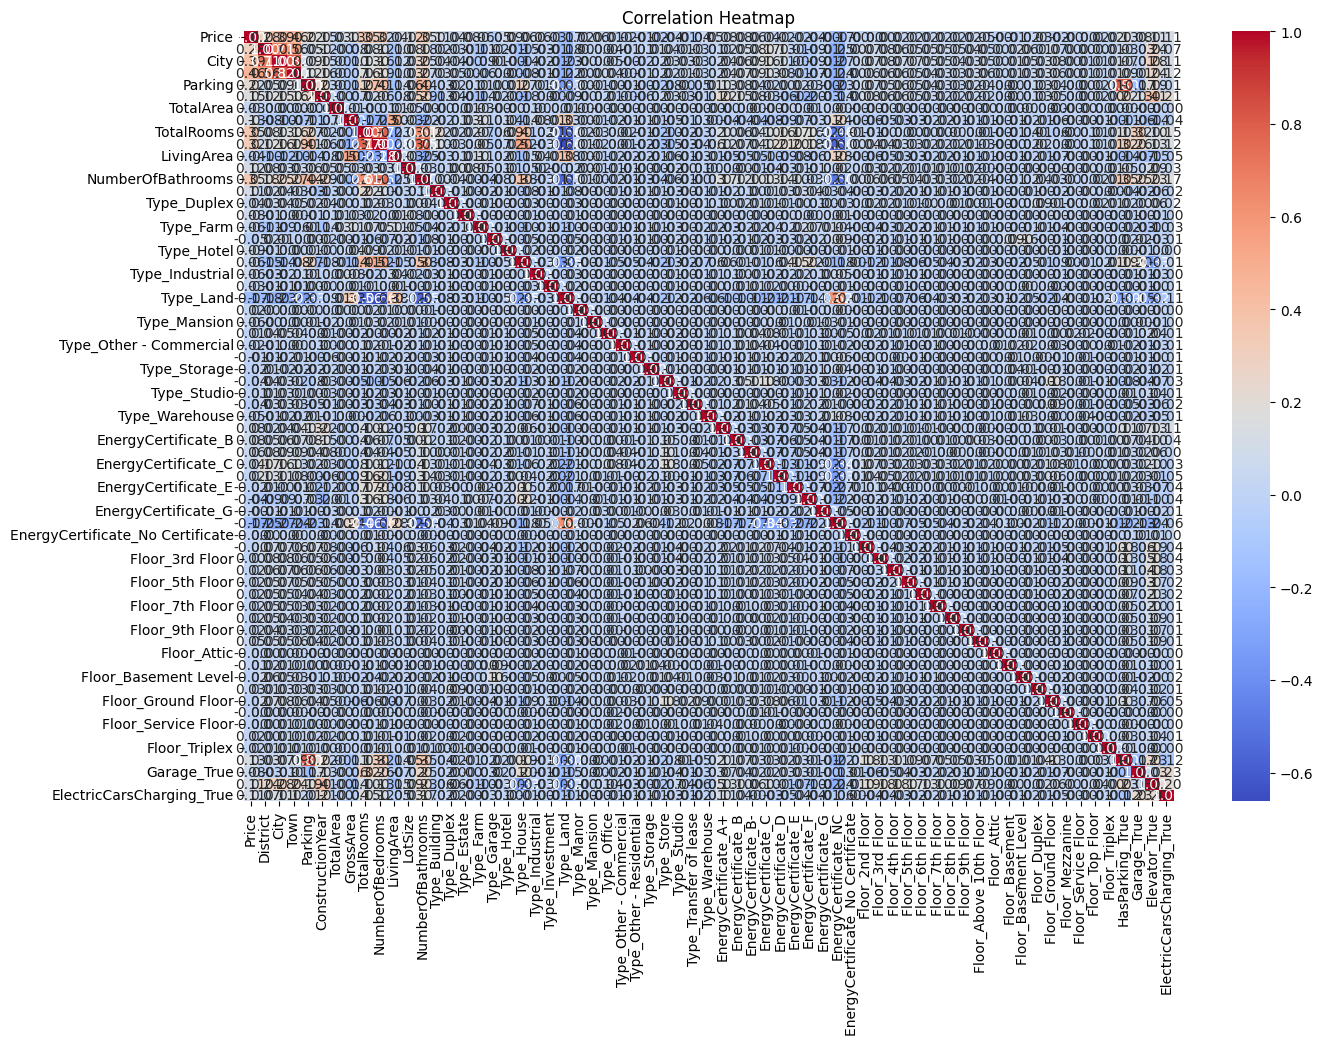

In [29]:
#correalation matrix
numerical_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(15, 10))
sns.heatmap(numerical_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# SHAP feature importance analysis

In [30]:
%pip install shap
%pip install xgboost
import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split


# Calculate correlation with the target variable
correlation = df.corr()['Price'].sort_values(ascending=False)
print(correlation)


X = df.drop(columns=['Price'])
y = df['Price']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Price                     1.000000
Town                      0.461112
City                      0.392663
TotalRooms                0.351932
NumberOfBathrooms         0.350504
                            ...   
Type_Store               -0.041461
Type_Transfer of lease   -0.044681
Type_Garage              -0.048963
EnergyCertificate_NC     -0.165053
Type_Land                -0.169575
Name: Price, Length: 65, dtype: float64


# Task 2
Train  a  glass-box  model  on  your  case  study  and  critically  analyze  the  interpretability  provided  by 
 the obtained model. 

In [31]:
from sklearn.tree import DecisionTreeRegressor

# Train a Random Forest classifier
model = DecisionTreeRegressor()
model.fit(X_train, y_train)

# Make predictions and evaluate the model
y_pred = model.predict(X_test)

In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Baseline model: Predict the mean of the target variable
y_baseline = [y_train.mean()] * len(y_test)
baseline_mse = mean_squared_error(y_test, y_baseline)
baseline_rmse = mean_squared_error(y_test, y_baseline, squared=False)
baseline_mae = mean_absolute_error(y_test, y_baseline)
baseline_r2 = r2_score(y_test, y_baseline)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")
print(f"Baseline Mean Squared Error: {baseline_mse}")
print(f"Baseline Root Mean Squared Error: {baseline_rmse}")
print(f"Baseline Mean Absolute Error: {baseline_mae}")
print(f"Baseline R-squared: {baseline_r2}")

Mean Squared Error: 0.41091180405473204
Root Mean Squared Error: 0.6410240276734812
Mean Absolute Error: 0.19554422507987024
R-squared: 0.6075352960434264
Baseline Mean Squared Error: 1.0470740810416461
Baseline Root Mean Squared Error: 1.0232663783402864
Baseline Mean Absolute Error: 0.5312077062546093
Baseline R-squared: -6.769136735562675e-05


# Task 3
Train  a  black-box  model  on  your  case  study  and  then  apply  post-hoc  XAI  techniques  ,  as 
 described below. 

In [33]:
import numpy as np
from xgboost import XGBRegressor

# Initialize XGBoost Regressor
xgboost_model = XGBRegressor(random_state=42, verbosity=0)

# Train the model
xgboost_model.fit(X_train, y_train)

# Predict on the test set
y_pred = xgboost_model.predict(X_test)

print("Predictions:", y_pred[:10])  # Display the first 10 predictions


Predictions: [-0.54820293 -0.01918065 -0.43436798 -0.5622311  -0.49108842 -0.30929118
 -0.30671304 -0.46721438  0.00256653 -0.5314625 ]


In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Baseline model: Predict the mean of the target variable
y_baseline = [y_train.mean()] * len(y_test)
baseline_mse = mean_squared_error(y_test, y_baseline)
baseline_rmse = mean_squared_error(y_test, y_baseline, squared=False)
baseline_mae = mean_absolute_error(y_test, y_baseline)
baseline_r2 = r2_score(y_test, y_baseline)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")
print(f"Baseline Mean Squared Error: {baseline_mse}")
print(f"Baseline Root Mean Squared Error: {baseline_rmse}")
print(f"Baseline Mean Absolute Error: {baseline_mae}")
print(f"Baseline R-squared: {baseline_r2}")

Mean Squared Error: 0.2380312045272328
Root Mean Squared Error: 0.4878844171801686
Mean Absolute Error: 0.1940134938433309
R-squared: 0.7726547514688481
Baseline Mean Squared Error: 1.0470740810416461
Baseline Root Mean Squared Error: 1.0232663783402864
Baseline Mean Absolute Error: 0.5312077062546093
Baseline R-squared: -6.769136735562675e-05


# Task 3.1
Apply  at  least  one  simplification-based  technique  and  assess  how  well  it  approximates 
 the black-box model.

### Global Surrogate: Generalized Additive Model (GAM)
- Captures non-linear relationships for individual features while remaining interpretable.
- Allows for partial dependence plots of individual features.

In [35]:
from pygam import LinearGAM, s, l

terms = s(0)
for i in range(1, X_train.shape[1]):
    terms += s(i)

# Define the GAM with smooth terms for each feature
gam = LinearGAM(terms)

# Train the GAM
gam.fit(X_test.values, y_pred)

# Predictions from GAM
y_gam_pred = gam.predict(X_test.values)

In [36]:
# Evaluate the model
mse = mean_squared_error(y_pred, y_gam_pred)
rmse = mean_squared_error(y_pred, y_gam_pred, squared=False)
mae = mean_absolute_error(y_pred, y_gam_pred)
r2 = r2_score(y_pred, y_gam_pred)

print(f"Surrogate Model RMSE: {rmse}")
print(f"Surrogate Model MAE: {mae}")
print(f"Surrogate Model R²: {r2:.2f}")
print(f"Surrogate Model MSE: {mse:.2f}")

Surrogate Model RMSE: 0.5342454670185611
Surrogate Model MAE: 0.2711149940029252
Surrogate Model R²: 0.64
Surrogate Model MSE: 0.29


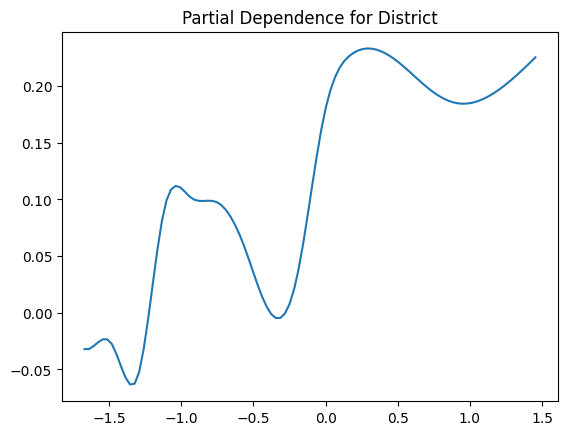

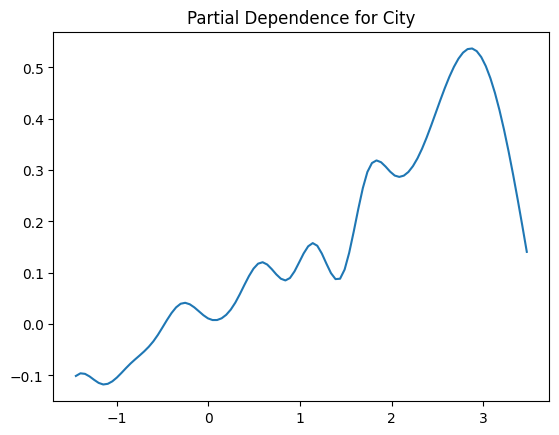

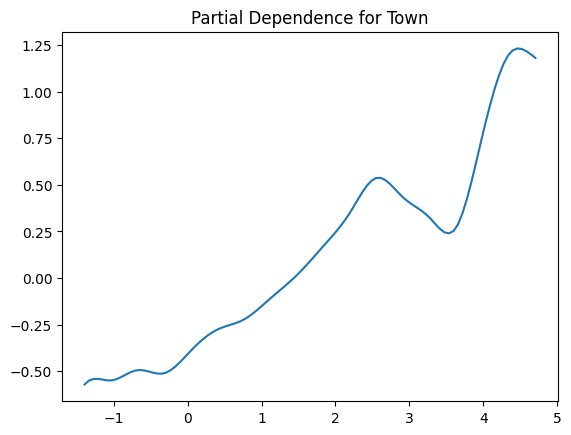

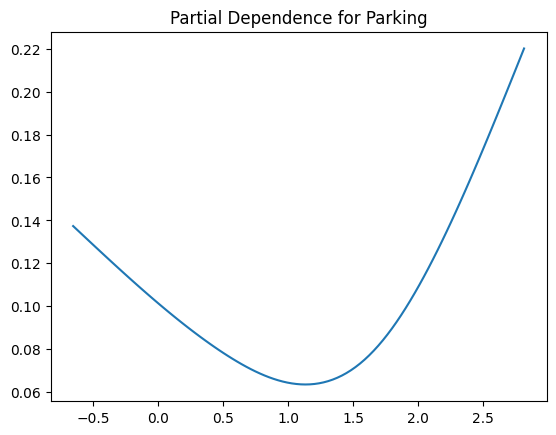

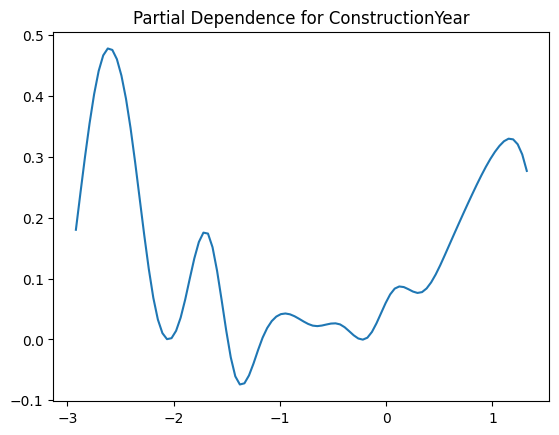

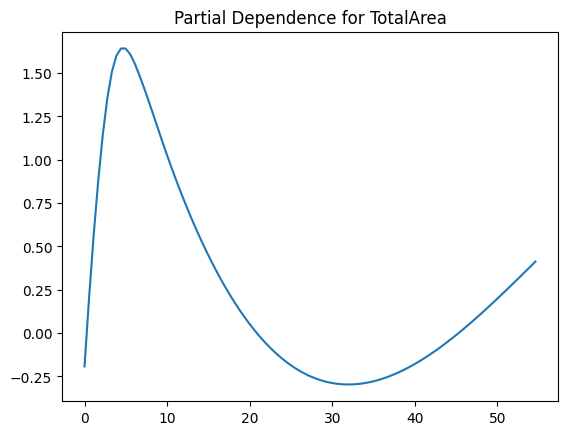

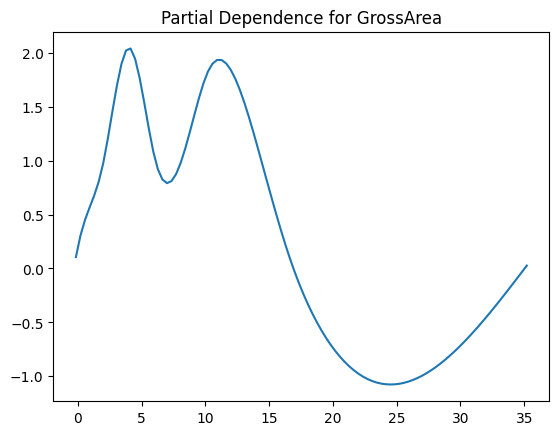

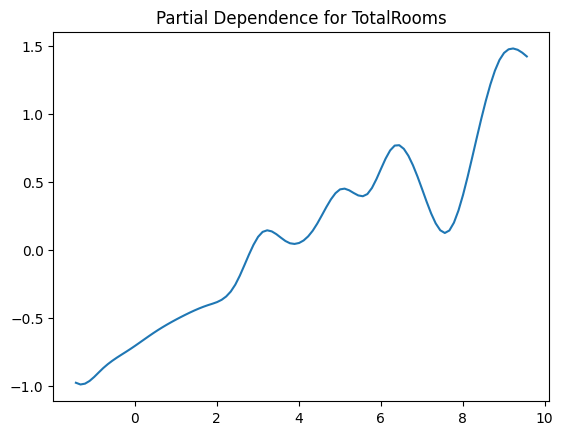

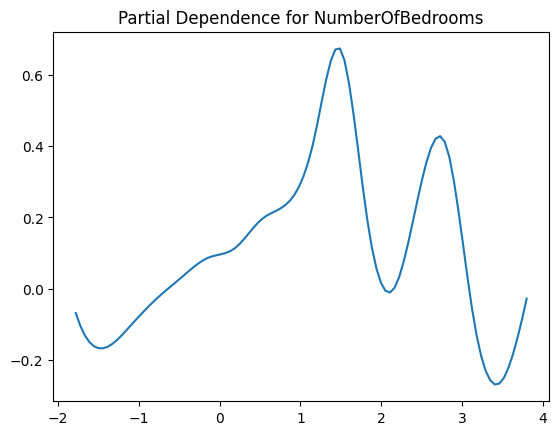

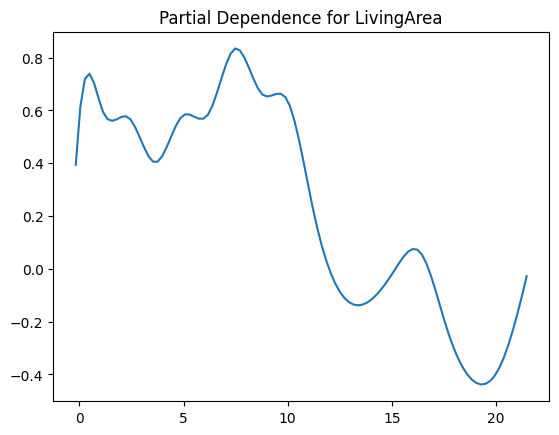

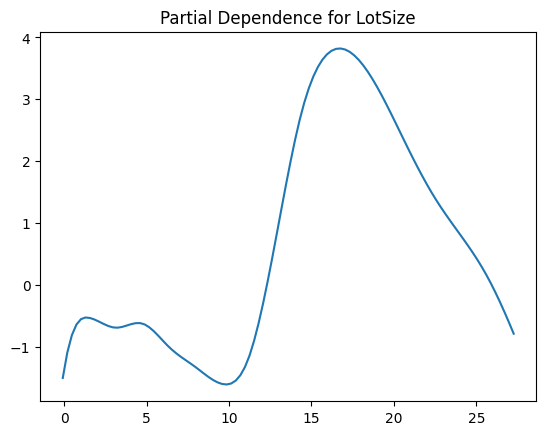

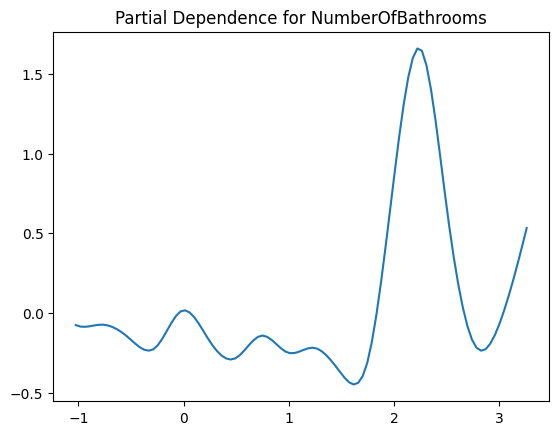

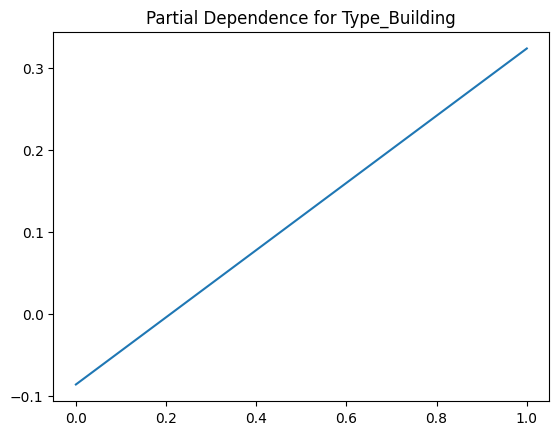

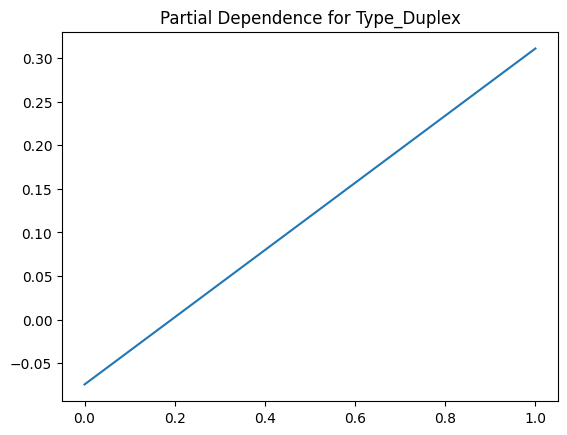

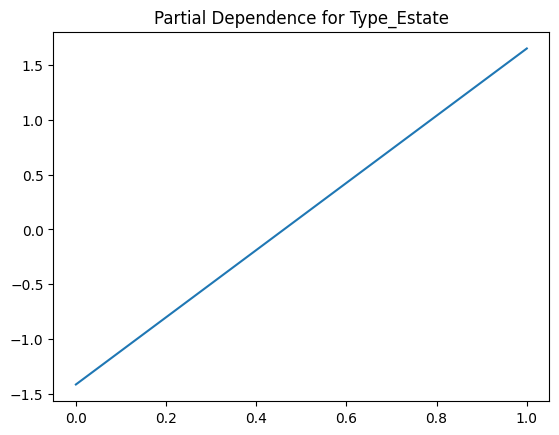

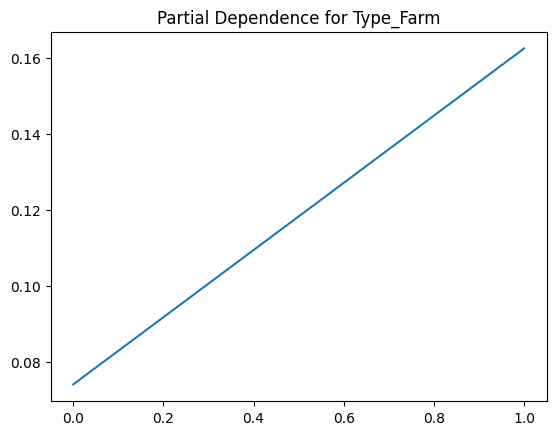

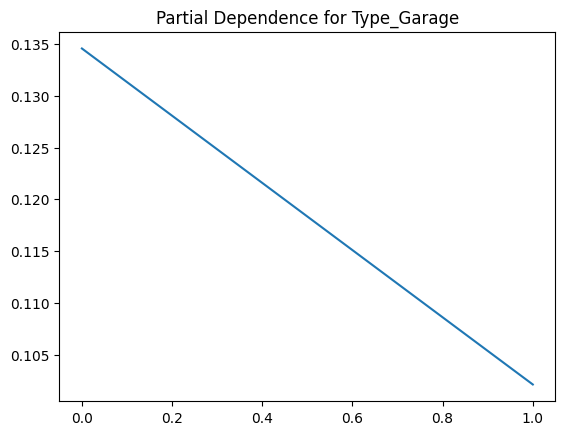

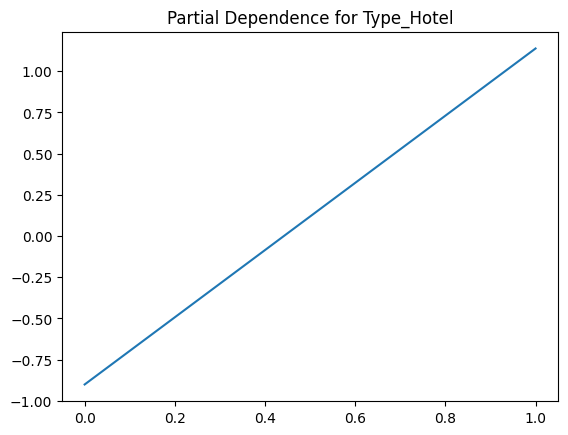

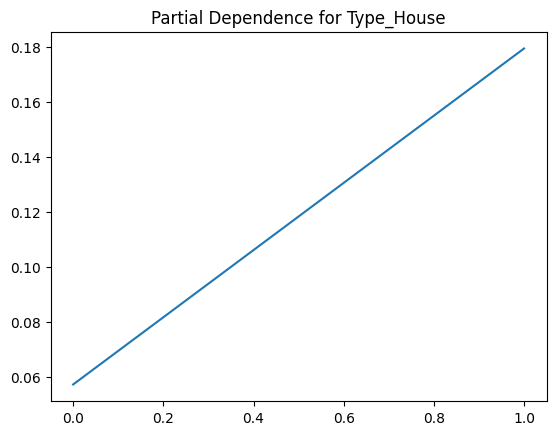

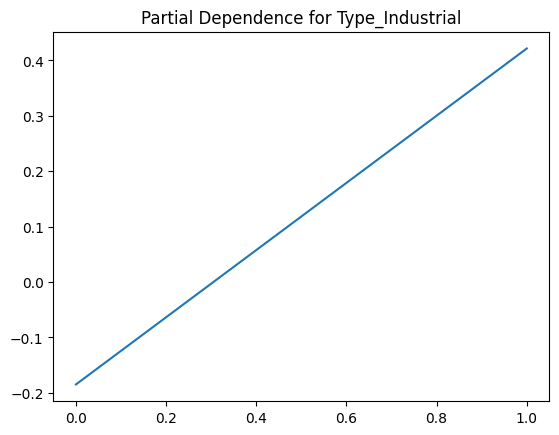

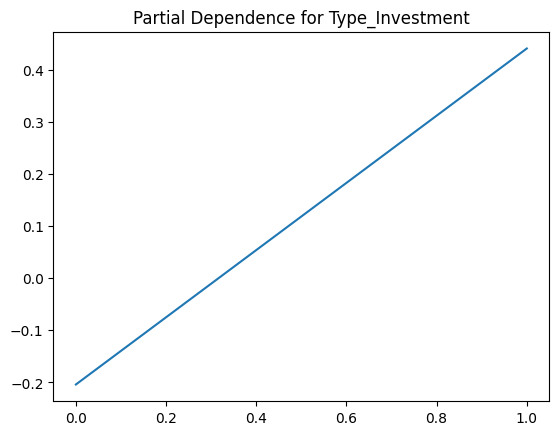

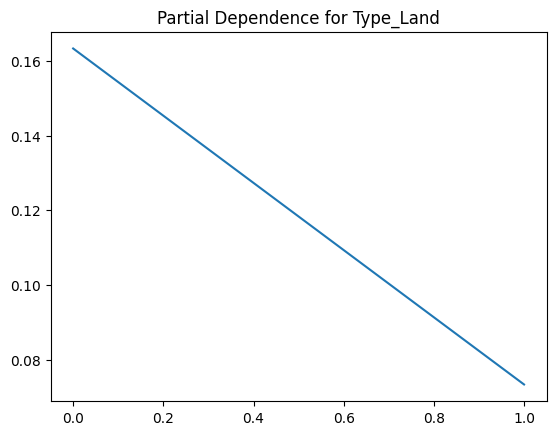

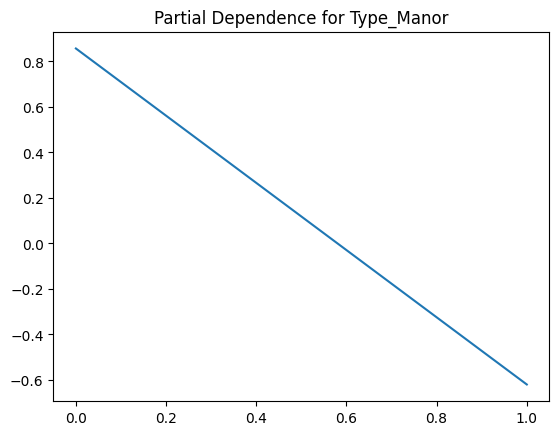

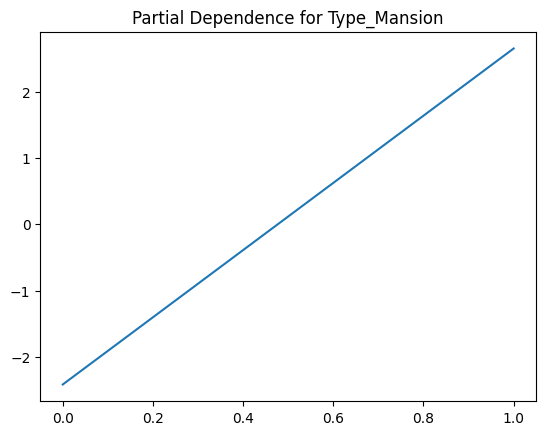

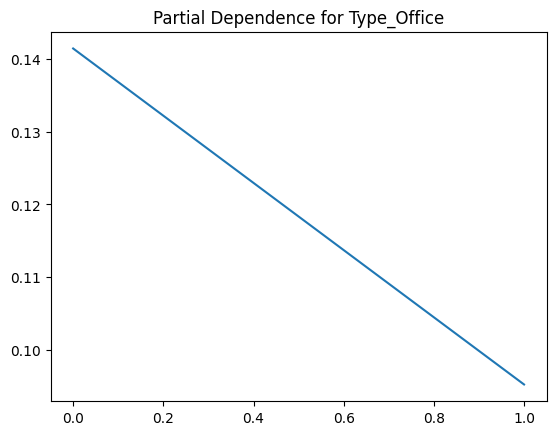

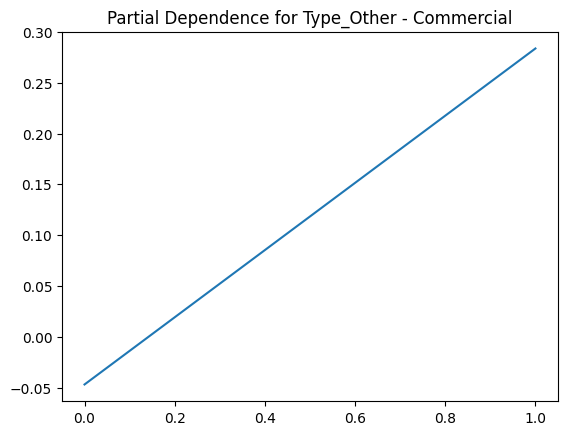

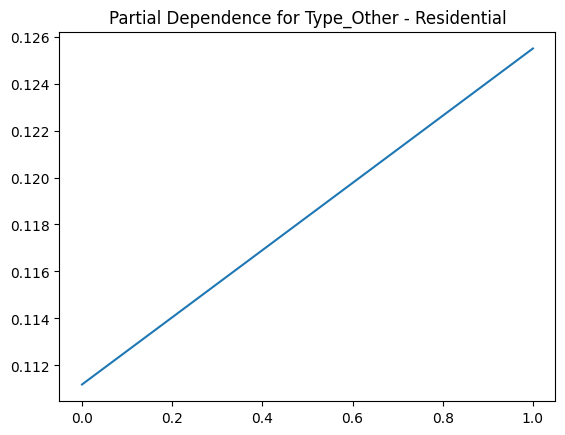

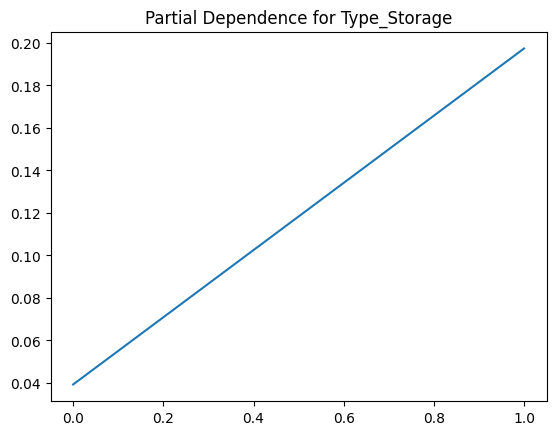

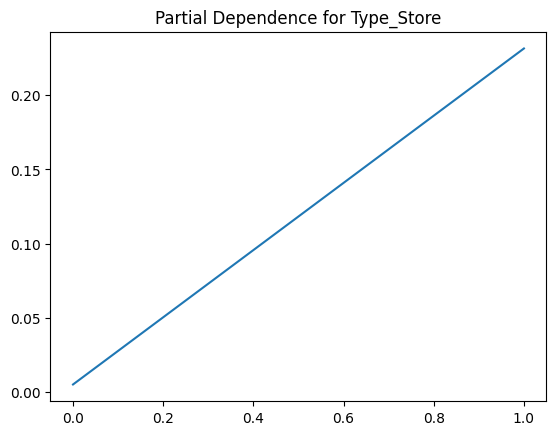

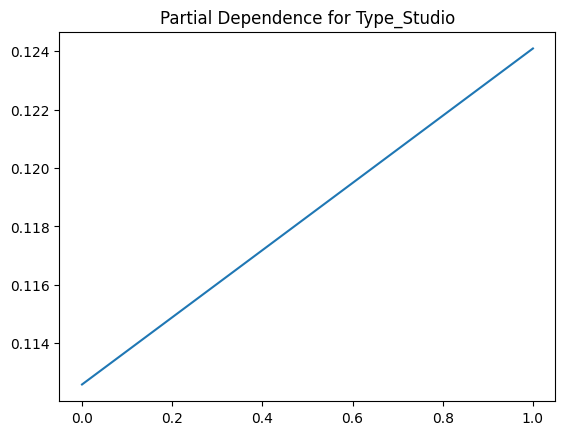

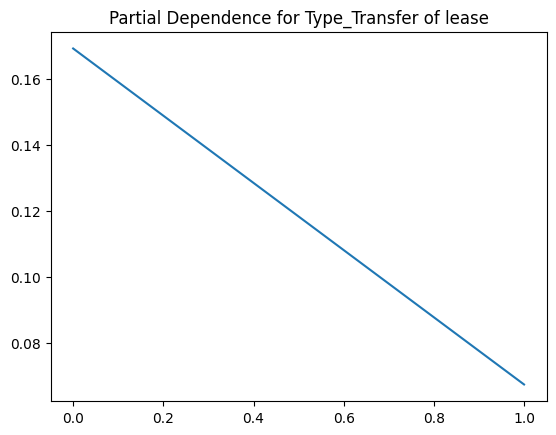

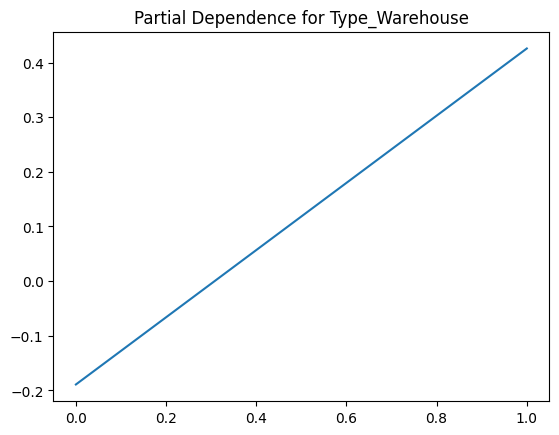

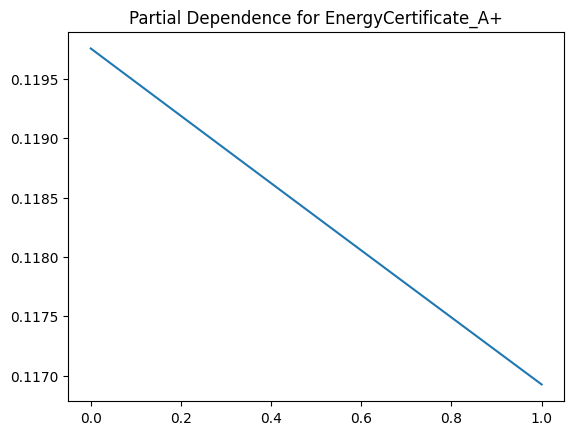

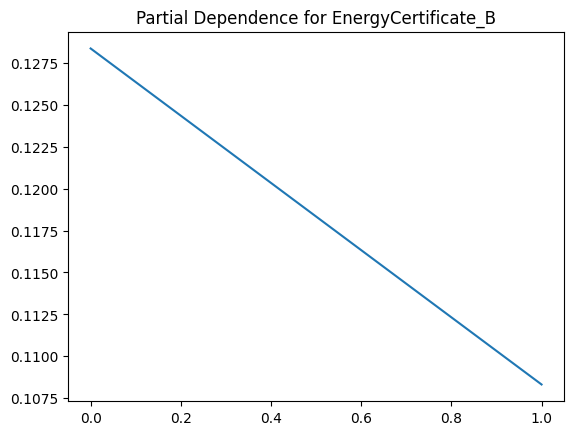

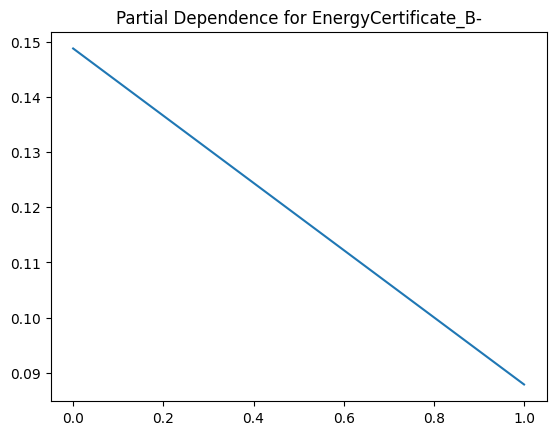

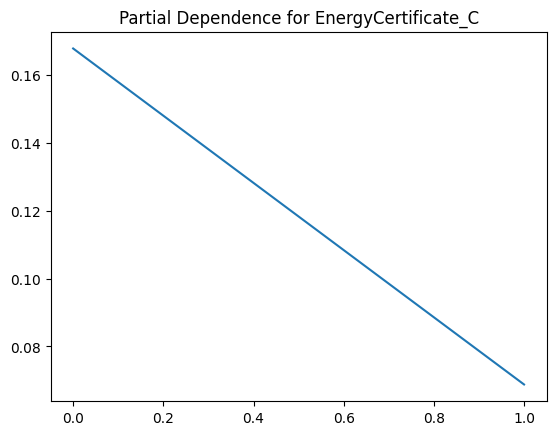

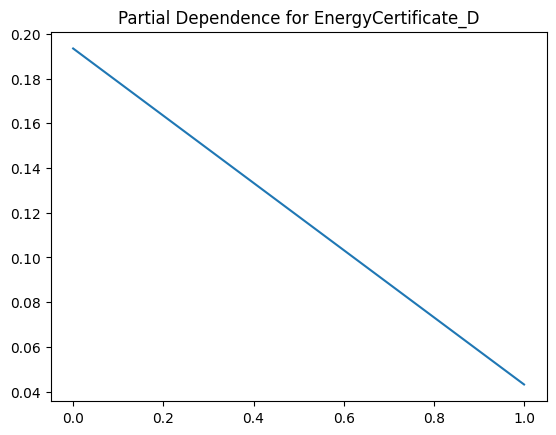

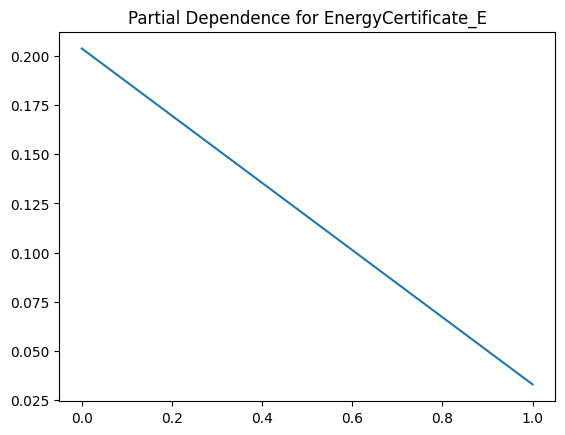

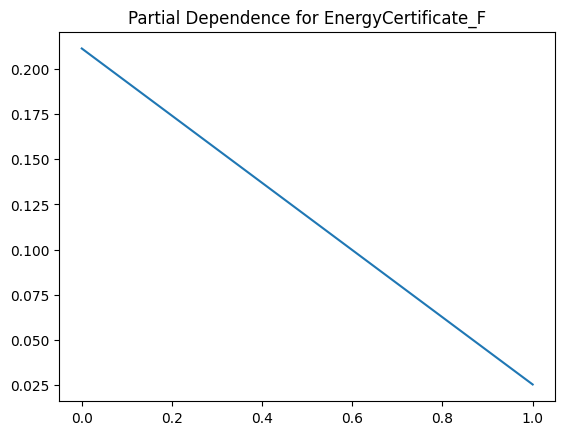

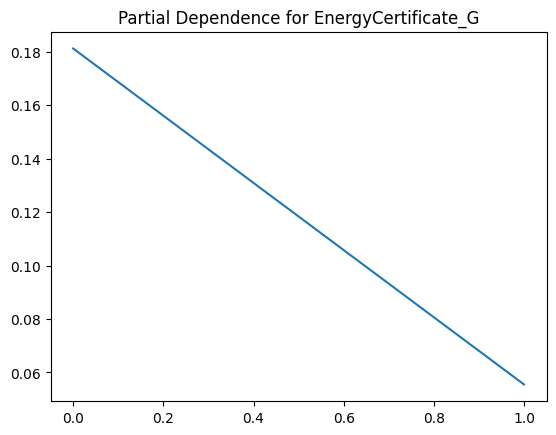

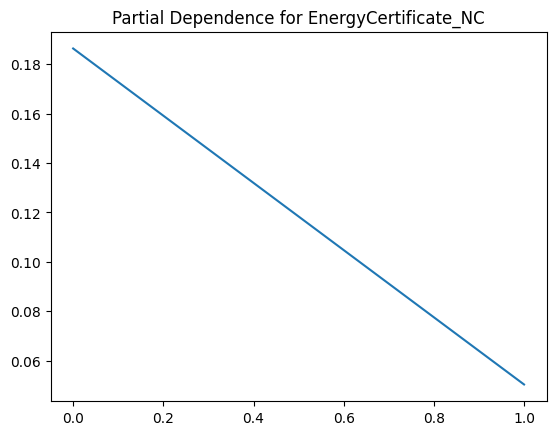

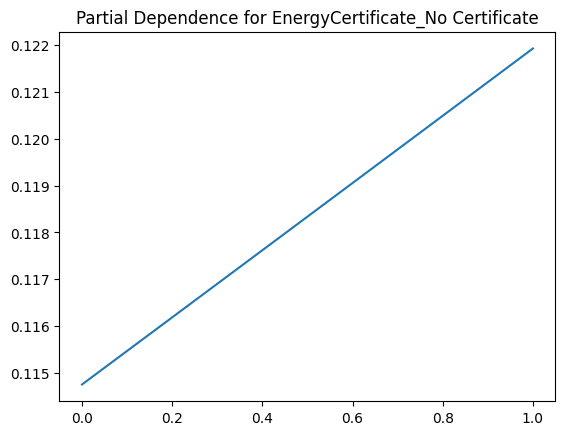

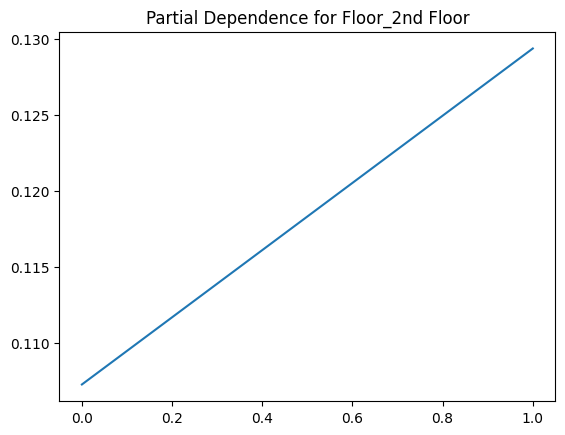

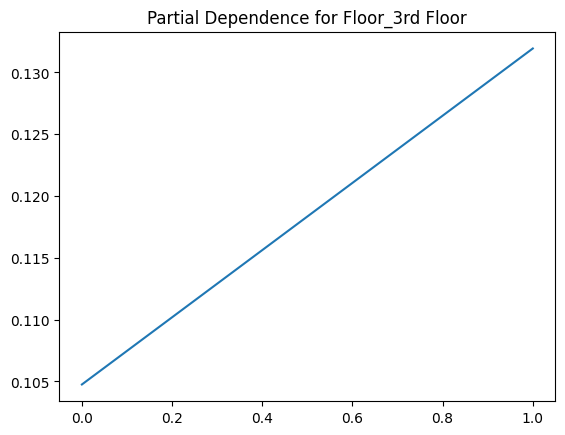

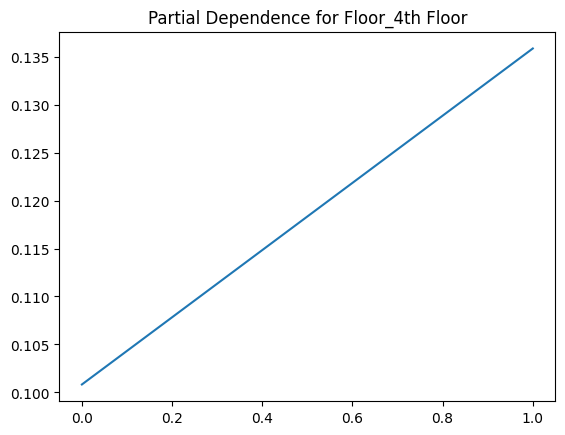

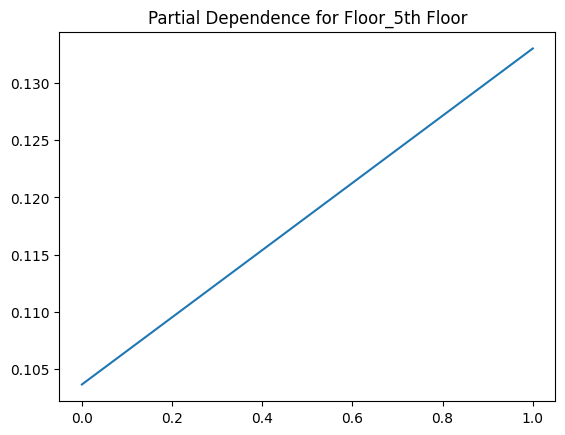

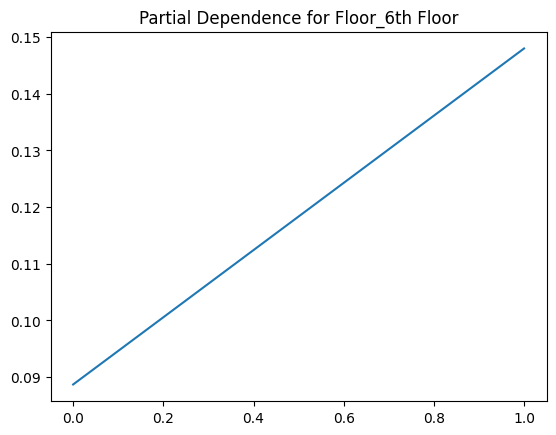

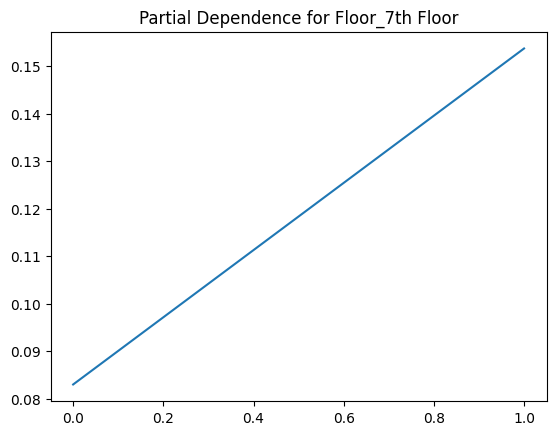

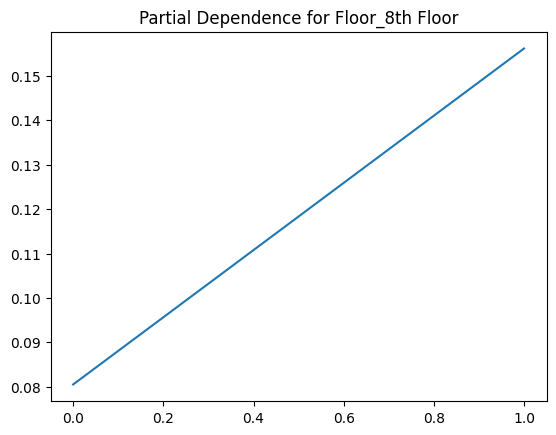

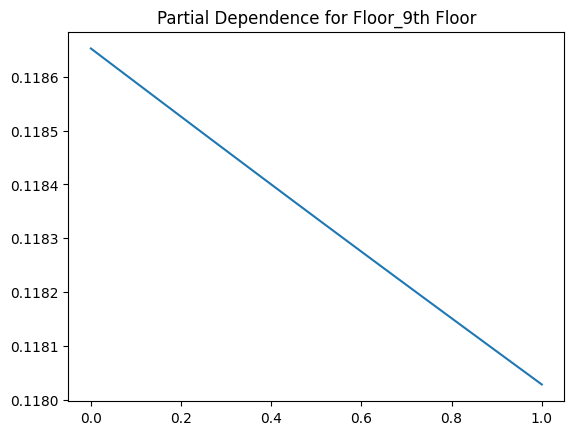

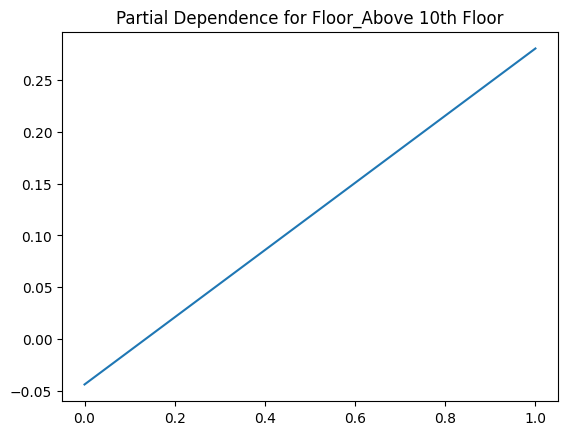

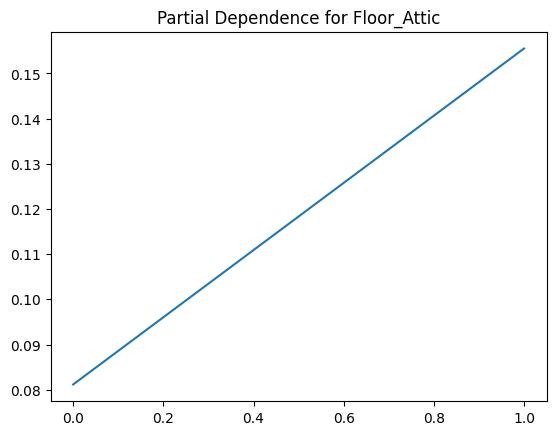

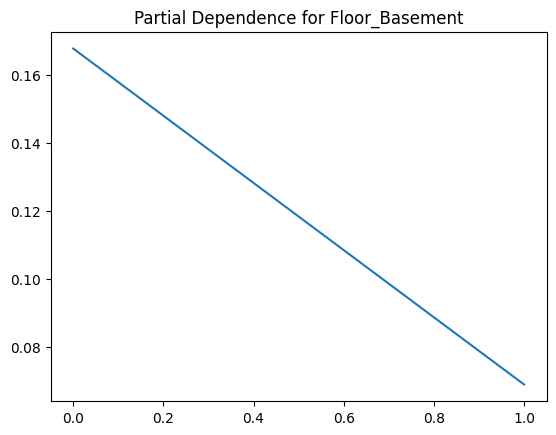

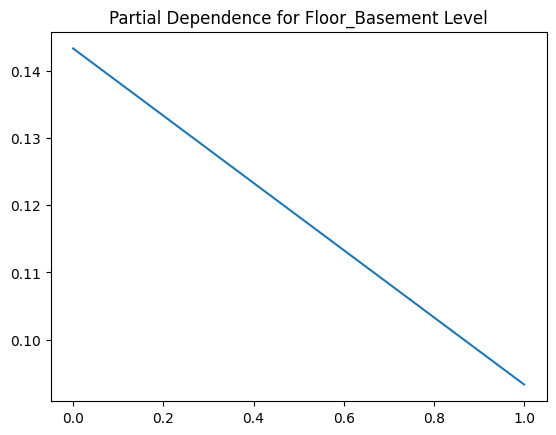

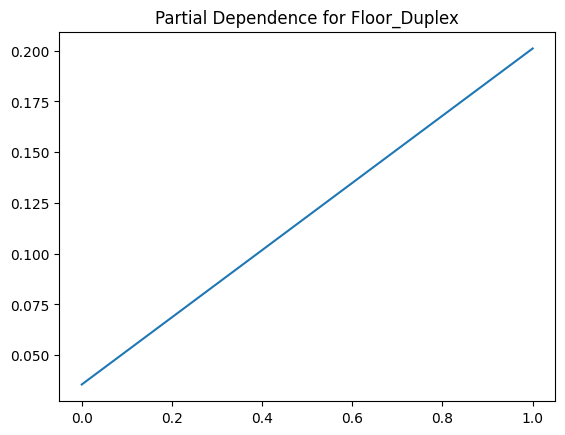

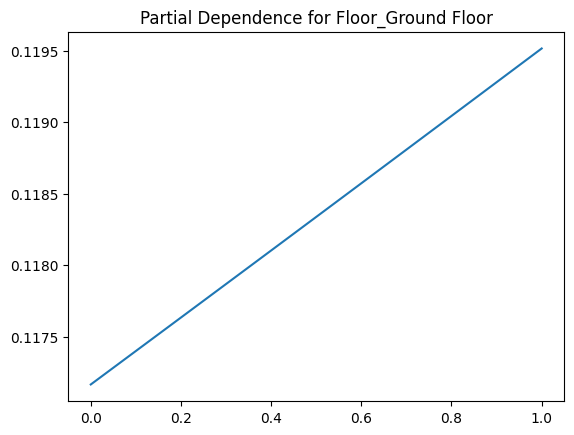

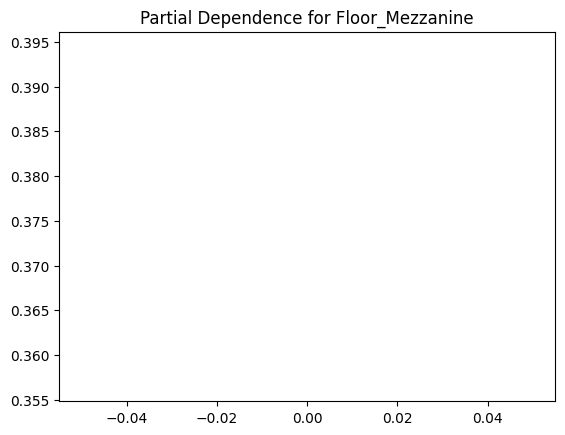

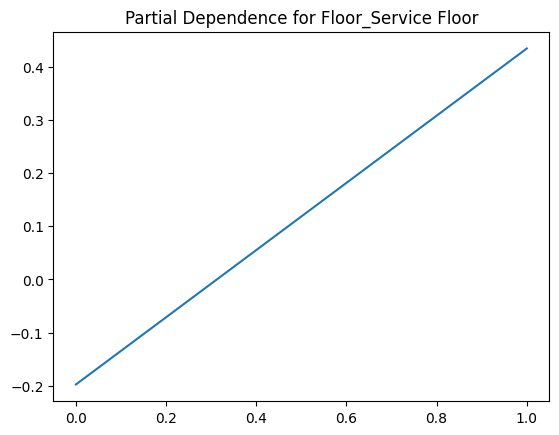

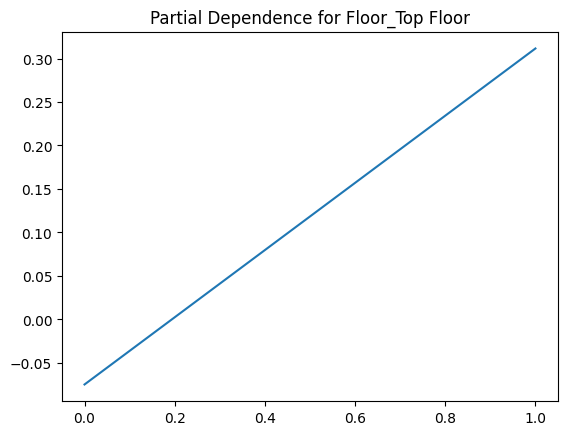

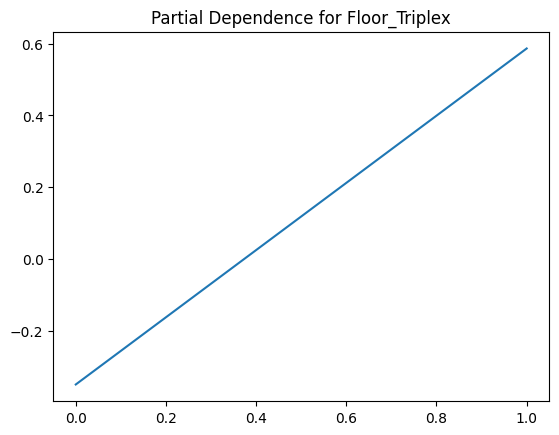

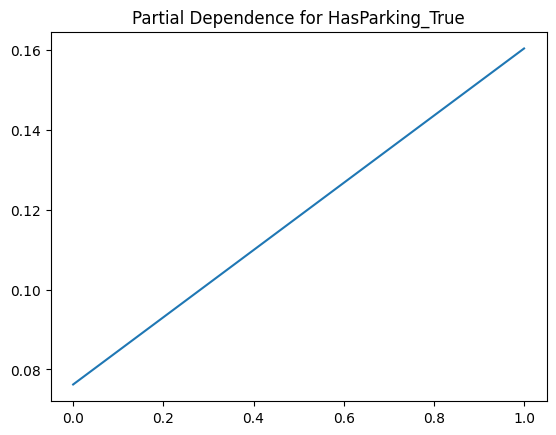

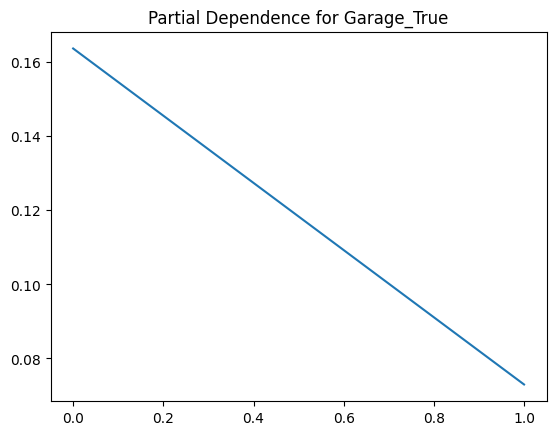

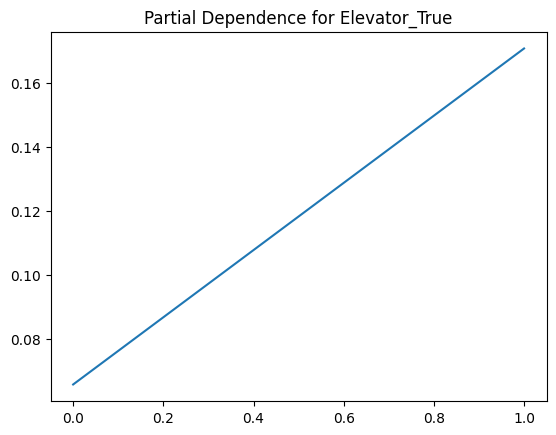

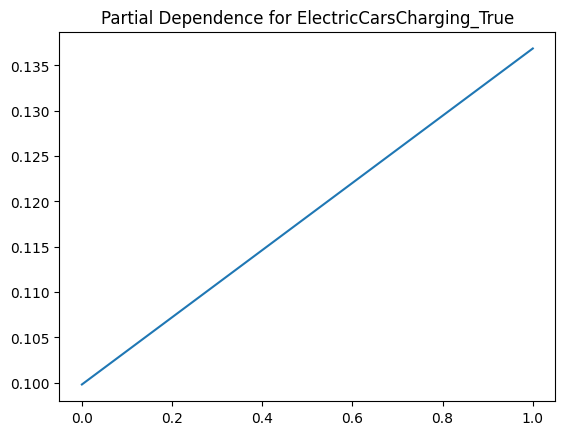

In [37]:
# Plot feature effects
for i, feature_name in enumerate(X_train.columns):
    plt.figure()
    XX = gam.generate_X_grid(term=i)
    plt.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    plt.title(f'Partial Dependence for {feature_name}')
    plt.show()

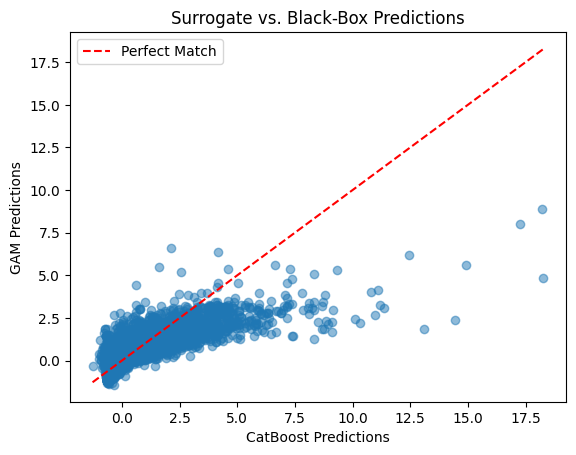

In [38]:
import matplotlib.pyplot as plt

# Scatter plot of GAM predictions vs. XGBoost predictions
plt.scatter(y_pred, y_gam_pred, alpha=0.5)
plt.plot([min(y_pred), max(y_pred)], [min(y_pred), max(y_pred)], color='red', linestyle='--', label='Perfect Match')
plt.title('Surrogate vs. Black-Box Predictions')
plt.xlabel('CatBoost Predictions')
plt.ylabel('GAM Predictions')
plt.legend()
plt.show()


### Conclusions about the surrogate model

## Rule Extraction

In [39]:
from sklearn.tree import DecisionTreeRegressor, export_text

# Fit a decision tree to the GAM predictions
tree = DecisionTreeRegressor(max_depth=5)  # Adjust depth for simplicity
tree.fit(X_test, y_gam_pred)

# Extract and display rules
rules = export_text(tree, feature_names=X_test.columns.tolist())
print(rules)


|--- Town <= 0.56
|   |--- NumberOfBathrooms <= 0.62
|   |   |--- GrossArea <= 1.95
|   |   |   |--- TotalRooms <= 2.44
|   |   |   |   |--- Town <= -0.16
|   |   |   |   |   |--- value: [-0.43]
|   |   |   |   |--- Town >  -0.16
|   |   |   |   |   |--- value: [-0.11]
|   |   |   |--- TotalRooms >  2.44
|   |   |   |   |--- LivingArea <= -0.09
|   |   |   |   |   |--- value: [0.72]
|   |   |   |   |--- LivingArea >  -0.09
|   |   |   |   |   |--- value: [2.04]
|   |   |--- GrossArea >  1.95
|   |   |   |--- LotSize <= 0.31
|   |   |   |   |--- GrossArea <= 2.47
|   |   |   |   |   |--- value: [0.42]
|   |   |   |   |--- GrossArea >  2.47
|   |   |   |   |   |--- value: [1.00]
|   |   |   |--- LotSize >  0.31
|   |   |   |   |--- Town <= -0.39
|   |   |   |   |   |--- value: [1.08]
|   |   |   |   |--- Town >  -0.39
|   |   |   |   |   |--- value: [2.55]
|   |--- NumberOfBathrooms >  0.62
|   |   |--- NumberOfBathrooms <= 2.19
|   |   |   |--- NumberOfBathrooms <= 1.19
|   |   |   |   

- Important Features:
    - The first split is on NumberOfBedrooms, suggesting it is the most influential feature in predicting the target.
    - Other key features include Town, TotalRooms, and NumberOfBathrooms.

- Ranges and Predictions:
    - For properties with 3 or fewer bedrooms, predicted values range from $103,072 to $794,933, depending on the Town value.
    - For properties with more than 3 bedrooms, predicted values range from $474,319 to $1,619,001, influenced by both Town, TotalRooms, and NumberOfBathrooms.

- Interpretable Rules:
    - If you want to extract rules from this tree, you can summarize it as:
        - Rule 1: For properties with NumberOfBedrooms <= 3 and Town <= 310,538, the predicted value is approximately $103,072.
        - Rule 2: For properties with NumberOfBedrooms > 3, Town > 525,022, and NumberOfBathrooms > 4.1, the predicted value is approximately $1,619,001.

- Feature Impact:
    - Smaller values of Town and fewer rooms generally lead to lower predictions.
    - Higher values of Town, more rooms, and more bathrooms correspond to higher predictions.

### Global analysis on the task

## Task 3.2
Apply  at  least  two  feature-based  techniques  and  compare  the  insights  obtained  from 
 the explanations generated by the two methods, whether they are consistent or not.

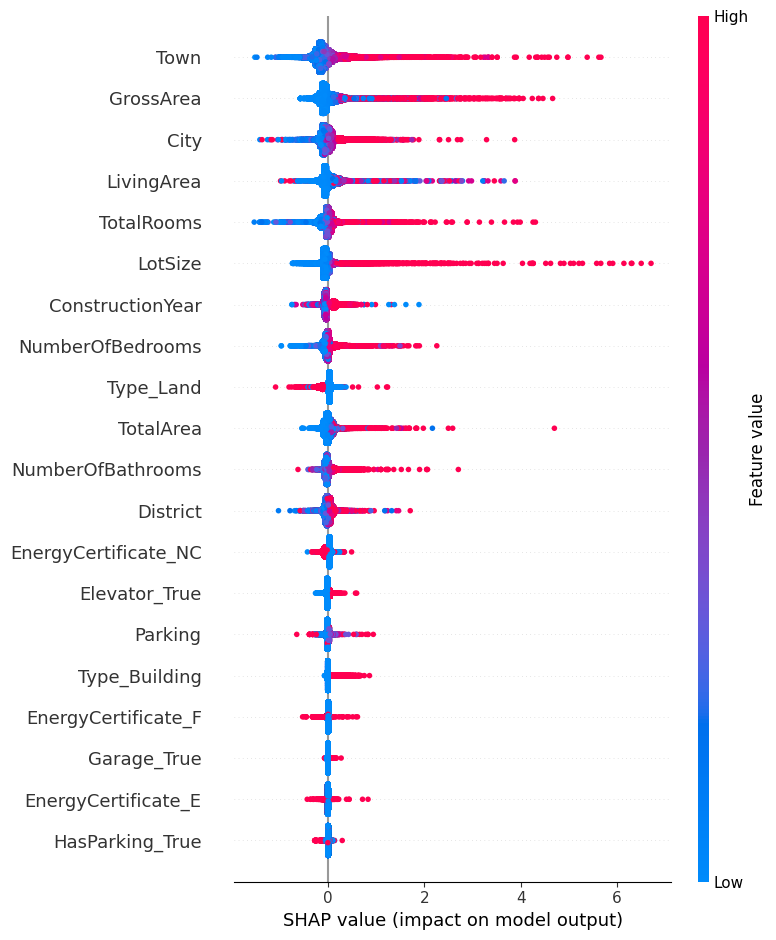

In [40]:
# Explain the model's predictions using SHAP
explainer = shap.TreeExplainer(xgboost_model)
shap_values = explainer.shap_values(X)

# Plot feature importance
shap.summary_plot(shap_values, X)
# Make predictions and evaluate the model

In [41]:
# LIME
import lime
import lime.lime_tabular
# Initialize the LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    mode='regression'
)

# Explain a single prediction
i = 0  # Index of the instance to explain
exp = explainer.explain_instance(
    data_row=X_test.iloc[i].values,
    predict_fn=xgboost_model.predict
)

# Show the explanation
exp.show_in_notebook(show_table=True)

### Global Analysis on the task 3.2

# Task 3.3
 Apply  at  least  one  example-based  technique  and  discuss  the  explanation  obtained  for 
 two different examples

# Task 3.3

### CounterFactual Explanations

In [43]:
import dice_ml
from dice_ml import Dice
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import pandas as pd


# Train an XGBoost regressor
xgboost_model = XGBRegressor(random_state=42, verbosity=0)
xgboost_model.fit(X_train, y_train)

continuous_features = X_train.select_dtypes(include=['number']).columns.tolist()

# Prepare the data for DiCE
data_dice = dice_ml.Data(
    dataframe=pd.concat([X_train, y_train], axis=1),
    continuous_features=continuous_features,
    outcome_name="Price"
)

# Initialize the model for DiCE
model_dice = dice_ml.Model(model=xgboost_model, backend="sklearn", model_type='regressor')
exp = dice_ml.Dice(data_dice, model_dice)

# Select an instance to explain
query_instances = X_train.iloc[0:1]
desired_range = [y_train.min(), y_train.max()]  # Ajusta para o intervalo desejado


# Generate counterfactual explanations
dice_exp = exp.generate_counterfactuals(query_instances,
                                                      total_CFs=4,
                                                      desired_range= desired_range,
                                                      verbose=False)

# Select an instance to explain
query_instances2 = X_train.iloc[1:2]
desired_range2 = [y_train.min(), y_train.max()]  # Ajusta para o intervalo desejado


# Generate counterfactual explanations
dice_exp2 = exp.generate_counterfactuals(query_instances2,
                                                      total_CFs=4,
                                                      desired_range= desired_range2,
                                                      verbose=False)

# Visualize the counterfactual explanations
dice_exp.visualize_as_dataframe()
dice_exp2.visualize_as_dataframe()


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:01<00:00,  1.58s/it]

Query instance (original outcome : -0.0)


,District,City,Town,Parking,ConstructionYear,TotalArea,GrossArea,TotalRooms,NumberOfBedrooms,LivingArea,...,Floor_Ground Floor,Floor_Mezzanine,Floor_Service Floor,Floor_Top Floor,Floor_Triplex,HasParking_True,Garage_True,Elevator_True,ElectricCarsCharging_True,Price
0,-0.015343,-0.330792,-0.682007,-0.654067,0.512935,-0.013243,-0.116186,-1.435517,-1.778046,-0.122144,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0



Diverse Counterfactual set (new outcome: [-0.6436062332690614, 23.322008717171112])


,District,City,Town,Parking,ConstructionYear,TotalArea,GrossArea,TotalRooms,NumberOfBedrooms,LivingArea,...,Floor_Ground Floor,Floor_Mezzanine,Floor_Service Floor,Floor_Top Floor,Floor_Triplex,HasParking_True,Garage_True,Elevator_True,ElectricCarsCharging_True,Price
0,-0.015343,-0.330792,-0.682007,-0.654067,0.512935,-0.013243,-0.116186,-1.435517,-1.778046,-0.122144,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.492450
1,-0.015343,-0.330792,-0.682007,-0.654067,0.512935,-0.013243,-0.116186,-1.435517,-1.778046,-0.122144,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.492450
2,-0.015343,-0.330792,-0.682007,-0.654067,-0.898202,-0.013243,-0.116186,-1.435517,-1.778046,-0.122144,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2,-0.522743
3,-0.015343,-0.330792,-0.682007,-0.654067,0.512935,-0.013243,-0.116186,-1.435517,-1.778046,-0.122144,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.373377


Query instance (original outcome : -0.0)


,District,City,Town,Parking,ConstructionYear,TotalArea,GrossArea,TotalRooms,NumberOfBedrooms,LivingArea,...,Floor_Ground Floor,Floor_Mezzanine,Floor_Service Floor,Floor_Top Floor,Floor_Triplex,HasParking_True,Garage_True,Elevator_True,ElectricCarsCharging_True,Price
0,-0.818631,-0.945914,-1.064638,-0.654067,0.82635,-0.013247,-0.118092,0.955777,1.010391,-0.12307,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0



Diverse Counterfactual set (new outcome: [-0.6436062332690614, 23.322008717171112])


,District,City,Town,Parking,ConstructionYear,TotalArea,GrossArea,TotalRooms,NumberOfBedrooms,LivingArea,...,Floor_Ground Floor,Floor_Mezzanine,Floor_Service Floor,Floor_Top Floor,Floor_Triplex,HasParking_True,Garage_True,Elevator_True,ElectricCarsCharging_True,Price
0,-0.818631,-0.945914,-1.064638,-0.654067,0.82635,-0.013247,-0.118092,0.492456,1.010391,-0.12307,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.423928
1,-0.818631,-0.945914,3.363500,-0.654067,0.82635,-0.013247,-0.118092,0.955777,1.010391,-0.12307,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.117326
2,-0.818631,-0.945914,0.048439,-0.654067,0.82635,-0.013247,-0.118092,0.955777,1.010391,-0.12307,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.209622
3,-0.818631,-0.945914,-1.064638,-0.654067,0.82635,-0.013247,-0.118092,7.746886,1.010391,-0.12307,...,0.0,0.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.541193


# TASK 4

Select at least one functionally-grounded metric to evaluate explanations generated by one of the
post-hoc XAI techniques. Discuss the results and suggest ways this metric could inform
interpretability improvements.

In [46]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from lime.lime_tabular import LimeTabularExplainer

# Make predictions and evaluate the model
y_pred = xgboost_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"Mean Absolute Error: {mae}")
print(f"R-squared: {r2}")


# Initialize the LIME explainer
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    mode="regression",
    kernel_width=1.0 
)


local_fidelities = []
for i in range(10):  # Test the first 10 instances
    exp = explainer.explain_instance(
        data_row=X_test.iloc[i].values,
        predict_fn=xgboost_model.predict,
        num_samples=2000
    )
    local_fidelities.append(exp.score)


# Show the explanation
exp.show_in_notebook(show_table=True)

average_local_fidelity = sum(local_fidelities) / len(local_fidelities)


# Calculate local fidelity
local_fidelity = average_local_fidelity
print(f"Local Fidelity: {local_fidelity}")


Mean Squared Error: 0.2380312045272328
Root Mean Squared Error: 0.4878844171801686
Mean Absolute Error: 0.1940134938433309
R-squared: 0.7726547514688481


Local Fidelity: 0.12246971026358189


In [47]:
import numpy as np
from lime.lime_tabular import LimeTabularExplainer
from sklearn.metrics import accuracy_score

def calculate_lime_coverage(model, X_train, X_test, threshold=0.1, num_samples=50):

    # Initialize the LIME explainer
    explainer = LimeTabularExplainer(
        training_data=X_train.values if hasattr(X_train, 'values') else X_train,
        feature_names=X_train.columns if hasattr(X_train, 'columns') else [f"Feature {i}" for i in range(X_train.shape[1])],
        mode="regression" if hasattr(model, "predict") else "classification",
        kernel_width=1
    )
    
    covered_count = 0
    total_count = min(num_samples, X_test.shape[0])
    
    for i in range(total_count):
        instance = X_test[i]
        explanation = explainer.explain_instance(instance, model.predict, num_features=X_test.shape[1])
        
        # Surrogate model predictions
        surrogate_preds = explanation.local_pred
        
        # Original model predictions
        original_preds = model.predict(instance.reshape(1, -1))[0]
        
        # Check if surrogate predictions align with original predictions
        if np.abs(surrogate_preds - original_preds) <= threshold:
            covered_count += 1
    
    # coverage as a percentage
    coverage = (covered_count / total_count) * 100
    return coverage

lime_coverage = calculate_lime_coverage(
    model=xgboost_model,
    X_train=X_train,
    X_test=X_test.values,
    threshold=0.1,  
    num_samples=50  
)

print(f"LIME Coverage: {lime_coverage:.2f}%")


LIME Coverage: 38.00%
